In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def read_routing_metrics(dir):
    df = pd.read_csv(f"{dir}/routing_metrics.csv")
    return df

def read_routing_partition_counts(dir):
    df = pd.read_csv(f"{dir}/routing_partition_counts.csv")
    return df

In [3]:
sift500_dirs = [
    "/dataset/surge-dont_copy/theoretical_partition_quality_sift-500M_10_20260429_211857",
    "/dataset/surge-dont_copy/theoretical_partition_quality_sift-500M_10_20260429_211457",
    "/dataset/surge-dont_copy/theoretical_partition_quality_sift-500M_10_20260429_211044",
    "/dataset/surge-dont_copy/theoretical_partition_quality_sift-500M_10_20260429_210605",
    "/dataset/surge-dont_copy/theoretical_partition_quality_sift-500M_10_20260429_210138"
]

msturing500_dirs = [
    "/dataset/surge-dont_copy/theoretical_partition_quality_msturing-500M_10_20260429_153730",
    "/dataset/surge-dont_copy/theoretical_partition_quality_msturing-500M_10_20260429_154457",
    "/dataset/surge-dont_copy/theoretical_partition_quality_msturing-500M_10_20260429_162603",
    "/dataset/surge-dont_copy/theoretical_partition_quality_msturing-500M_10_20260429_162843",
    "/dataset/surge-dont_copy/theoretical_partition_quality_msturing-500M_10_20260429_163133",
    "/dataset/surge-dont_copy/theoretical_partition_quality_msturing-500M_10_20260429_163419",
    "/dataset/surge-dont_copy/theoretical_partition_quality_msturing-500M_10_20260429_163704"
]

In [4]:
sift500_dfs = [read_routing_metrics(dir) for dir in sift500_dirs]
msturing500_dfs = [read_routing_metrics(dir) for dir in msturing500_dirs]

In [5]:
modes = ["branching_factor", "recall_target", "nprobe"]
params = {
    "branching_factor": [1, 2, 5, 10, 15, 20, 25, 30, 35, 40, 50],
    "recall_target": [0.5, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.97, 0.98, 0.99],
    "nprobe": [1, 2, 3, 4, 5, 6, 7, 8, 9]
}

In [6]:
sift500_dfs[1][sift500_dfs[1]["mode"] == modes[1]]

,mode,param,recall,activation,imbalance,query_time_s
11,recall_target,0.50,0.79692,0.11037,0.098779,0.048083
12,recall_target,0.70,0.88789,0.13991,0.109630,0.047970
13,recall_target,0.75,0.90732,0.14941,0.111366,0.047598
14,recall_target,0.80,0.92837,0.16208,0.114376,0.047768
15,recall_target,0.85,0.94906,0.17838,0.115574,0.047607
16,recall_target,0.90,0.96767,0.20093,0.119477,0.047699
17,recall_target,0.95,0.98626,0.24063,0.118462,0.047629
18,recall_target,0.97,0.99272,0.26996,0.110299,0.047874
19,recall_target,0.98,0.99556,0.29374,0.104530,0.048056
20,recall_target,0.99,0.99812,0.33449,0.092238,0.048285


In [7]:
for df in sift500_dfs:
    df["QPS"] = 10000 / df['query_time_s']
for df in msturing500_dfs:
    df["QPS"] = 10000 / df['query_time_s']

In [8]:
from functools import reduce

# Join all dataframes on 'mode' and 'param'
# Selecting only the columns you want from each dataframe
def merge_dfs(df_list):
    def merge_func(left, right_tuple):
        idx, right = right_tuple
        return pd.merge(
            left,
            right[['mode', 'param', 'recall', 'activation', 'imbalance', 'QPS']],
            on=['mode', 'param'],
            how='outer',
            suffixes=('', f'_run{idx}')
        )
    
    result = df_list[0][['mode', 'param', 'recall', 'activation', 'imbalance', 'QPS']]
    for idx, df in enumerate(df_list[1:], 1):
        result = merge_func(result, (idx, df))
    return result

sift500_combined = merge_dfs(sift500_dfs)
sift500_combined

,mode,param,recall,activation,imbalance,QPS,recall_run1,activation_run1,imbalance_run1,QPS_run1,...,imbalance_run2,QPS_run2,recall_run3,activation_run3,imbalance_run3,QPS_run3,recall_run4,activation_run4,imbalance_run4,QPS_run4
0,branching_factor,1.00,0.74564,0.10000,0.076205,220183.324636,0.74270,0.10000,0.088091,217897.679608,...,0.091905,220613.216497,0.74159,0.10000,0.073198,217729.258022,0.75306,0.10000,0.087483,220274.506089
1,branching_factor,2.00,0.86542,0.13610,0.082676,220047.662324,0.86481,0.13659,0.093956,219112.288474,...,0.105999,220219.691164,0.86254,0.13632,0.079494,216948.917208,0.86820,0.13468,0.096147,219241.031398
2,branching_factor,5.00,0.95504,0.19376,0.083776,219076.286745,0.95476,0.19312,0.097150,218383.525147,...,0.111629,217542.638357,0.95349,0.19410,0.079967,217327.995758,0.95531,0.18935,0.105299,215596.696196
3,branching_factor,10.00,0.98423,0.24466,0.078949,218741.318704,0.98343,0.24388,0.096223,218039.260149,...,0.112420,215769.282222,0.98394,0.24456,0.070952,217642.539540,0.98364,0.23874,0.103396,215218.069709
4,branching_factor,15.00,0.99205,0.27840,0.073698,218388.294387,0.99195,0.27775,0.091618,217450.866977,...,0.108248,215050.988589,0.99137,0.27769,0.062856,216857.175696,0.99239,0.27273,0.095374,216191.909234
5,branching_factor,20.00,0.99521,0.30422,0.069021,216698.340741,0.99526,0.30336,0.085481,216179.757792,...,0.106884,215840.537011,0.99483,0.30376,0.058634,216053.650442,0.99562,0.29753,0.091773,216696.462430
6,branching_factor,25.00,0.99677,0.32646,0.070119,216744.369523,0.99673,0.32427,0.080013,215569.275342,...,0.102538,214642.941467,0.99638,0.32495,0.054926,214571.093841,0.99735,0.31950,0.090035,215568.345944
7,branching_factor,30.00,0.99766,0.34516,0.069270,215724.131980,0.99783,0.34309,0.078367,216182.094502,...,0.100440,215758.574785,0.99746,0.34318,0.054918,215862.901154,0.99806,0.33822,0.086704,215660.860357
8,branching_factor,35.00,0.99832,0.36212,0.068819,215781.853178,0.99837,0.36001,0.077199,216435.693709,...,0.099882,215374.277419,0.99815,0.35994,0.053354,214249.291906,0.99861,0.35589,0.082365,215225.480975
9,branching_factor,40.00,0.99872,0.37676,0.070115,213367.472129,0.99883,0.37530,0.075986,215488.912018,...,0.097033,213633.673794,0.99864,0.37506,0.052623,212358.860992,0.99899,0.37183,0.081164,214443.176847


In [9]:
msturing500_combined = merge_dfs(msturing500_dfs)
msturing500_combined

,mode,param,recall,activation,imbalance,QPS,recall_run1,activation_run1,imbalance_run1,QPS_run1,...,imbalance_run4,QPS_run4,recall_run5,activation_run5,imbalance_run5,QPS_run5,recall_run6,activation_run6,imbalance_run6,QPS_run6
0,branching_factor,1.00,0.59954,0.10000,0.282894,171004.772743,0.60888,0.10000,0.280808,167195.841505,...,0.247483,169942.304588,0.61392,0.10000,0.380141,171295.059165,0.60047,0.10000,0.313283,170227.832932
1,branching_factor,2.00,0.73050,0.15523,0.285903,170005.576183,0.74065,0.15341,0.310288,167018.519013,...,0.264372,169930.175691,0.74326,0.15279,0.362094,170750.448220,0.73351,0.15514,0.327846,169119.748620
2,branching_factor,5.00,0.86286,0.26295,0.278981,169414.858022,0.86621,0.25510,0.306098,167131.012329,...,0.271434,168526.923019,0.86585,0.25309,0.340234,169364.932313,0.86263,0.25994,0.321364,168135.328763
3,branching_factor,10.00,0.92579,0.37580,0.248212,169136.625183,0.92650,0.36288,0.276034,167255.405695,...,0.251270,167746.957070,0.92686,0.35948,0.293184,169201.302173,0.92221,0.36988,0.284921,168020.068317
4,branching_factor,15.00,0.95093,0.45529,0.223668,168346.200595,0.95098,0.44027,0.245742,166903.391310,...,0.228627,167691.822676,0.95036,0.43650,0.259171,168970.580532,0.94905,0.44902,0.253731,167873.396599
5,branching_factor,20.00,0.96419,0.51783,0.201713,166625.288053,0.96383,0.50081,0.221353,166442.801099,...,0.209081,167570.429852,0.96356,0.49676,0.232602,168279.910071,0.96229,0.51140,0.229357,166905.341305
6,branching_factor,25.00,0.97298,0.56802,0.184685,165083.788277,0.97201,0.54957,0.200127,166088.402213,...,0.193106,166284.212977,0.97166,0.54680,0.209042,167815.644446,0.97065,0.56260,0.209264,165780.294691
7,branching_factor,30.00,0.97876,0.61141,0.171153,166559.790801,0.97801,0.59275,0.182492,166051.170329,...,0.179961,165750.618250,0.97702,0.58936,0.191977,166817.080067,0.97707,0.60643,0.192495,164068.370571
8,branching_factor,35.00,0.98271,0.64826,0.158170,166489.078316,0.98220,0.62875,0.167411,166693.337601,...,0.166986,166377.170390,0.98090,0.62473,0.176870,168060.447982,0.98124,0.64326,0.176512,164494.516575
9,branching_factor,40.00,0.98533,0.67933,0.147025,166327.082207,0.98523,0.66108,0.153406,166547.862525,...,0.156149,166370.527128,0.98405,0.65670,0.164382,168045.762222,0.98426,0.67492,0.163234,165635.036448


In [10]:
msturing500_combined['AVG_QPS'] = msturing500_combined[[col for col in msturing500_combined.columns if col.startswith('QPS')]].mean(axis=1)
msturing500_combined['AVG_recall'] = msturing500_combined[[col for col in msturing500_combined.columns if col.startswith('recall')]].mean(axis=1)

msturing500_combined['25P_QPS'] = msturing500_combined[[col for col in msturing500_combined.columns if col.startswith('QPS')]].quantile(0.25, axis=1)
msturing500_combined['75P_QPS'] = msturing500_combined[[col for col in msturing500_combined.columns if col.startswith('QPS')]].quantile(0.75, axis=1)

msturing500_combined['25P_recall'] = msturing500_combined[[col for col in msturing500_combined.columns if col.startswith('recall')]].quantile(0.25, axis=1)
msturing500_combined['75P_recall'] = msturing500_combined[[col for col in msturing500_combined.columns if col.startswith('recall')]].quantile(0.75, axis=1) 

In [23]:
sift500_combined['AVG_QPS'] = sift500_combined[[col for col in sift500_combined.columns if col.startswith('QPS')]].mean(axis=1)
sift500_combined['AVG_recall'] = sift500_combined[[col for col in sift500_combined.columns if col.startswith('recall')]].mean(axis=1)

sift500_combined['25P_QPS'] = sift500_combined[[col for col in sift500_combined.columns if col.startswith('QPS')]].quantile(0.25, axis=1)
sift500_combined['75P_QPS'] = sift500_combined[[col for col in sift500_combined.columns if col.startswith('QPS')]].quantile(0.75, axis=1)

sift500_combined['25P_recall'] = sift500_combined[[col for col in sift500_combined.columns if col.startswith('recall')]].quantile(0.25, axis=1)
sift500_combined['75P_recall'] = sift500_combined[[col for col in sift500_combined.columns if col.startswith('recall')]].quantile(0.75, axis=1) 

In [24]:
sift500_combined_branching_factor = sift500_combined[sift500_combined['mode'] == 'branching_factor']
sift500_combined_recall_target = sift500_combined[sift500_combined['mode'] == 'recall_target']
sift500_combined_nprobe = sift500_combined[sift500_combined['mode'] == 'nprobe']

In [25]:
msturing500_combined_branching_factor = msturing500_combined[msturing500_combined['mode'] == 'branching_factor']
msturing500_combined_recall_target = msturing500_combined[msturing500_combined['mode'] == 'recall_target']
msturing500_combined_nprobe = msturing500_combined[msturing500_combined['mode'] == 'nprobe']

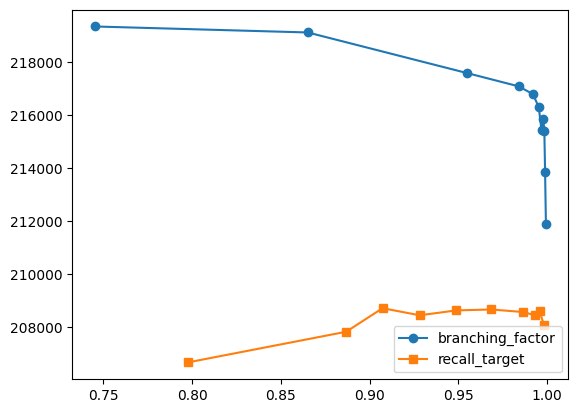

In [26]:
# TODO: add error bars for recall and QPS
plt.plot(sift500_combined_branching_factor['AVG_recall'], sift500_combined_branching_factor['AVG_QPS'], marker='o', label='branching_factor')
plt.plot(sift500_combined_recall_target['AVG_recall'], sift500_combined_recall_target['AVG_QPS'], marker='s', label='recall_target')
# plt.plot(sift500_combined_nprobe['AVG_recall'], sift500_combined_nprobe['AVG_QPS'], marker='^', label='nprobe')
plt.legend()
# plt.yscale('log')

ValueError: x and y must have same first dimension, but have shapes (10,) and (0,)

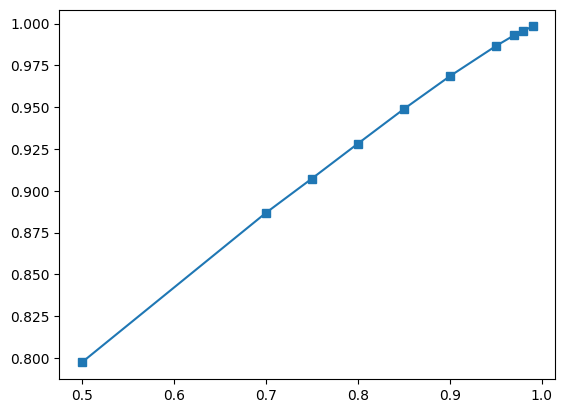

In [27]:
# TODO: add error bars for recall and QPS
plt.plot(sift500_combined_recall_target['param'], sift500_combined_recall_target['AVG_recall'], marker='s', label='theoretical recall')
plt.plot(sift500_combined_recall_target['param'], [], marker="o", label="real recall")
plt.plot(sift500_combined_recall_target['param'], sift500_combined_recall_target['param'], color="grey", alpha=0.5, ls=":")
# plt.plot(sift500_combined_nprobe['AVG_recall'], sift500_combined_nprobe['AVG_QPS'], marker='^', label='nprobe')
plt.legend()
# plt.yscale('log')

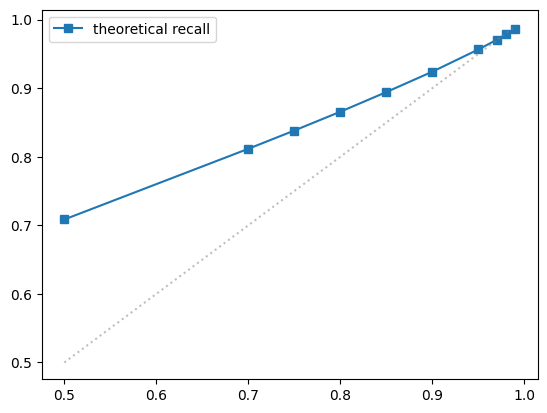

In [ ]:
# TODO: add error bars for recall and QPS
plt.plot(msturing500_combined_recall_target['param'], msturing500_combined_recall_target['AVG_recall'], marker='s', label='theoretical recall')
# plt.plot(msturing500_combined_recall_target['param'], [0.68197, 0.78248, 0.82724], marker="o", label="real recall")
plt.plot(msturing500_combined_recall_target['param'], msturing500_combined_recall_target['param'], color="grey", alpha=0.5, ls=":")
# plt.plot(sift500_combined_nprobe['AVG_recall'], sift500_combined_nprobe['AVG_QPS'], marker='^', label='nprobe')
plt.legend()
# plt.yscale('log')

In [28]:
msturing500_combined_nprobe["AVG_recall"]

11    0.599639
12    0.777856
13    0.864534
14    0.915264
15    0.947071
16    0.967569
17    0.981487
18    0.990643
19    0.996580
Name: AVG_recall, dtype: float64

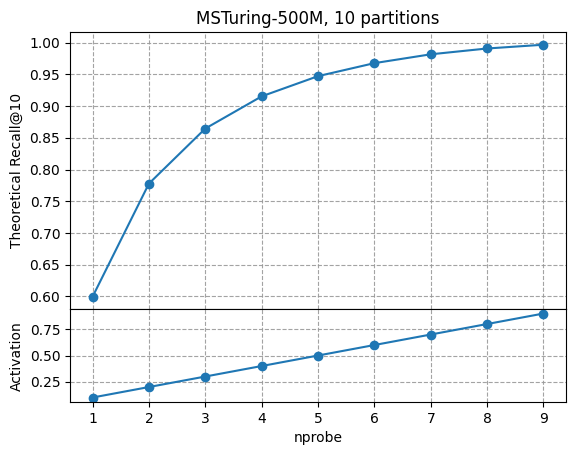

In [29]:
nprobes = msturing500_combined_nprobe['param']
recalls = msturing500_combined_nprobe["AVG_recall"]
activations = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

fig, (ax_top, ax_bottom) = plt.subplots(
	2,
	1,
	sharex=True,
	gridspec_kw={'height_ratios': [3, 1], 'hspace': 0}
)
ax_top.plot(nprobes, recalls, marker='o')
ax_top.set_ylabel('Theoretical Recall@10')
ax_top.set_axisbelow(True)
ax_top.grid(True, which='major', axis='both', linestyle='--', linewidth=0.8, color='0.6', alpha=0.9)
ax_bottom.plot(nprobes, activations, marker='o')
ax_bottom.set_xlabel('nprobe')
ax_bottom.set_ylabel('Activation')
ax_bottom.set_axisbelow(True)
ax_bottom.grid(True, which='major', axis='both', linestyle='--', linewidth=0.8, color='0.6', alpha=0.9)
# save plot
ax_top.set_title('MSTuring-500M, 10 partitions')
plt.savefig('msturing500M_recallvsnprobe.pdf')

In [30]:
sift500_combined_nprobe

,mode,param,recall,activation,imbalance,QPS,recall_run1,activation_run1,imbalance_run1,QPS_run1,...,recall_run4,activation_run4,imbalance_run4,QPS_run4,AVG_QPS,AVG_recall,25P_QPS,75P_QPS,25P_recall,75P_recall
11,nprobe,1.0,0.74564,0.1,0.076205,216557.557750,0.74270,0.1,0.088091,215218.996089,...,0.75306,0.1,0.087483,215928.156384,215487.092072,0.745304,215218.996089,216013.980425,0.74270,0.74564
12,nprobe,2.0,0.92537,0.2,0.081790,97126.983819,0.92550,0.2,0.099266,96448.756776,...,0.92789,0.2,0.081074,92207.540733,95966.395762,0.925840,95910.381340,97126.983819,0.92530,0.92550
13,nprobe,3.0,0.98017,0.3,0.069664,66420.909302,0.97883,0.3,0.080657,66318.714478,...,0.97998,0.3,0.082519,63830.466282,65589.383739,0.979692,65507.618536,66318.714478,0.97961,0.97998
14,nprobe,4.0,0.99542,0.4,0.072570,51293.362126,0.99476,0.4,0.067417,51337.601199,...,0.99561,0.4,0.080851,50254.034143,50891.398623,0.995192,50352.720809,51293.362126,0.99484,0.99542
15,nprobe,5.0,0.99888,0.5,0.098189,40702.691262,0.99884,0.5,0.072142,40536.213026,...,0.99874,0.5,0.079961,38874.354200,39964.899196,0.998814,39089.068351,40622.169143,0.99874,0.99888
16,nprobe,6.0,0.99971,0.6,0.100702,31406.739258,0.99970,0.6,0.070681,31861.034910,...,0.99961,0.6,0.080305,30924.806333,31241.554762,0.999670,30924.806333,31406.739258,0.99961,0.99971
17,nprobe,7.0,0.99991,0.7,0.098713,25579.307364,0.99987,0.7,0.069317,26372.142578,...,0.99987,0.7,0.079086,25595.151255,25708.633927,0.999888,25518.601785,25595.151255,0.99987,0.99991
18,nprobe,8.0,0.99998,0.8,0.091243,21510.788736,0.99996,0.8,0.069106,22114.500035,...,0.99995,0.8,0.075725,21385.388220,21576.514475,0.999962,21385.388220,21510.788736,0.99995,0.99998
19,nprobe,9.0,1.00000,0.9,0.063811,17398.293923,0.99998,0.9,0.058026,17912.287112,...,0.99999,0.9,0.054391,17053.176922,17455.826123,0.999988,17398.293923,17479.675507,0.99998,1.00000


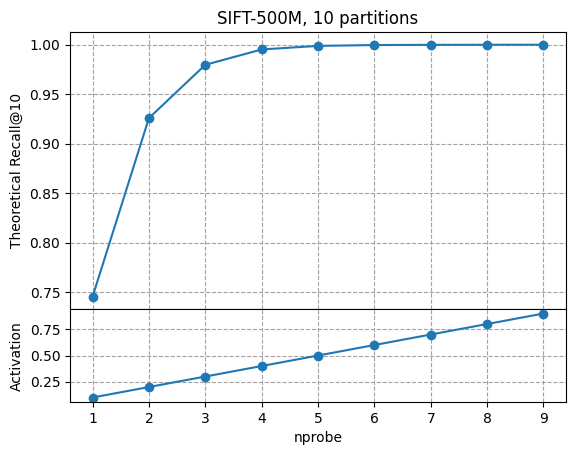

In [31]:
nprobes = sift500_combined_nprobe['param']
recalls = sift500_combined_nprobe["AVG_recall"]
activations = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

fig, (ax_top, ax_bottom) = plt.subplots(
	2,
	1,
	sharex=True,
	gridspec_kw={'height_ratios': [3, 1], 'hspace': 0}
)
ax_top.plot(nprobes, recalls, marker='o')
ax_top.set_ylabel('Theoretical Recall@10')
ax_top.set_axisbelow(True)
ax_top.grid(True, which='major', axis='both', linestyle='--', linewidth=0.8, color='0.6', alpha=0.9)
ax_bottom.plot(nprobes, activations, marker='o')
ax_bottom.set_xlabel('nprobe')
ax_bottom.set_ylabel('Activation')
ax_bottom.set_axisbelow(True)
ax_bottom.grid(True, which='major', axis='both', linestyle='--', linewidth=0.8, color='0.6', alpha=0.9)
# save plot
ax_top.set_title('SIFT-500M, 10 partitions')
plt.savefig('sift500M_recallvsnprobe.pdf')

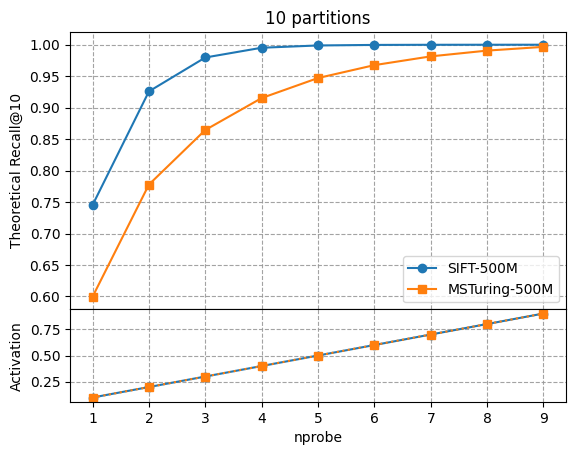

In [35]:
sift500_nprobes = sift500_combined_nprobe['param']
sift500_recalls = sift500_combined_nprobe["AVG_recall"]

msturing500_nprobes = msturing500_combined_nprobe['param']
msturing500_recalls = msturing500_combined_nprobe["AVG_recall"]
activations = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

fig, (ax_top, ax_bottom) = plt.subplots(
	2,
	1,
	sharex=True,
	gridspec_kw={'height_ratios': [3, 1], 'hspace': 0}
)
ax_top.plot(sift500_nprobes, sift500_recalls, marker='o', label="SIFT-500M")
ax_top.plot(msturing500_nprobes, msturing500_recalls, marker='s', label="MSTuring-500M")
ax_top.set_ylabel('Theoretical Recall@10')
ax_top.set_axisbelow(True)
ax_top.grid(True, which='major', axis='both', linestyle='--', linewidth=0.8, color='0.6', alpha=0.9)
ax_top.legend()
ax_bottom.plot(sift500_nprobes, activations, marker='o')
ax_bottom.plot(sift500_nprobes, activations, marker='s', linestyle=":")
ax_bottom.set_xlabel('nprobe')
ax_bottom.set_ylabel('Activation')
ax_bottom.set_axisbelow(True)
ax_bottom.grid(True, which='major', axis='both', linestyle='--', linewidth=0.8, color='0.6', alpha=0.9)
# save plot
ax_top.set_title('10 partitions')
plt.savefig('sift500M_recallvsnprobe.pdf')